# A* Search

A* Search is an **informed search algorithm** that combines the actual cost from the start node with the estimated cost from the current node to the goal.

\[
f(n) = g(n) + h(n)
\]

Where:

- **\(g(n)\)**: Actual cost from the start state to node \(n\).
- **\(h(n)\)**: Estimated cost from node \(n\) to the goal.
- **\(f(n)\)**: Estimated total cost of a solution through node \(n\).

A* always expands the node with the **lowest \(f(n)\)** value.

Unlike **Greedy Best-First Search**, which considers only \(h(n)\), A* considers both the cost already incurred and the estimated future cost.

- **Tree Search:** A* is optimal if \(h(n)\) is **admissible**.

In [ ]:
import heapq       # priority queue (min-heap) — like you'd build in C
import math         # for sqrt
import networkx as nx
import matplotlib.pyplot as plt
%matplotlib inline

## Step 1 — Node coordinates
Each node's (x, y) position. This is what the heuristic (straight-line distance) will be computed from.

In [ ]:
nodes = {
    'A': (0, 3),
    'B': (2, 5),
    'C': (5, 5),
    'D': (7, 3),
    'E': (5, 0),
    'F': (2, 0),
    'G': (7, 0),
}


## Step 2 — Edges + weight (written directly)
Each edge is made of three things: `(node1, node2, weight)`. Every edge here has weight `1` — like building an array of `struct Edge { char u, v; int weight; }` in C.

In [ ]:
edges = [
    ('A', 'B', 1),
    ('A', 'F', 100),
    ('B', 'C', 10000),
    ('C', 'D', 1),
    ('C', 'E', 100),
    ('D', 'G', 1),
    ('E', 'G', 1),
    ('E', 'F', 1),
    ('F', 'G', 1),
]

## Step 3 — Build the adjacency list
This is exactly like building an adjacency list from an edge array in C — two explicit loops, no shortcuts.

The graph is **undirected**, so for every edge `(u, v, w)` we add an entry on both sides: add `v` to `u`'s neighbour list, and add `u` to `v`'s neighbour list.

In [ ]:
def build_graph(edges):
    graph = {}   # dictionary = like a hash map / array-of-lists in C

    for u, v, w in edges:
        if u not in graph:
            graph[u] = []          # first time seeing this node, create an empty list
        if v not in graph:
            graph[v] = []

        graph[u].append((v, w))    # u -> v, cost w
        graph[v].append((u, w))    # v -> u, cost w (undirected, both directions)

    return graph

graph = build_graph(edges)

# sanity check: print the adjacency list to make sure it's correct
for node in graph:
    print(node, "->", graph[node])

A -> [('B', 1), ('F', 100)]
B -> [('A', 1), ('C', 10000)]
F -> [('A', 100), ('E', 1), ('G', 1)]
C -> [('B', 10000), ('D', 1), ('E', 100)]
D -> [('C', 1), ('G', 1)]
E -> [('C', 100), ('G', 1), ('F', 1)]
G -> [('D', 1), ('E', 1), ('F', 1)]


## Step 4 — Heuristic h(n)
h(n) = straight-line distance from the current node to the goal (Euclidean distance). Just the Pythagoras theorem — like writing `sqrt(dx*dx + dy*dy)` in C.

In [ ]:
def heuristic(node, goal):
    x1, y1 = nodes[node]
    x2, y2 = nodes[goal]
    dx = x1 - x2
    dy = y1 - y2
    return math.sqrt(dx * dx + dy * dy)

## Helper to draw the graph
(This is only for drawing — there's no A* logic in here, just take it as-is.)

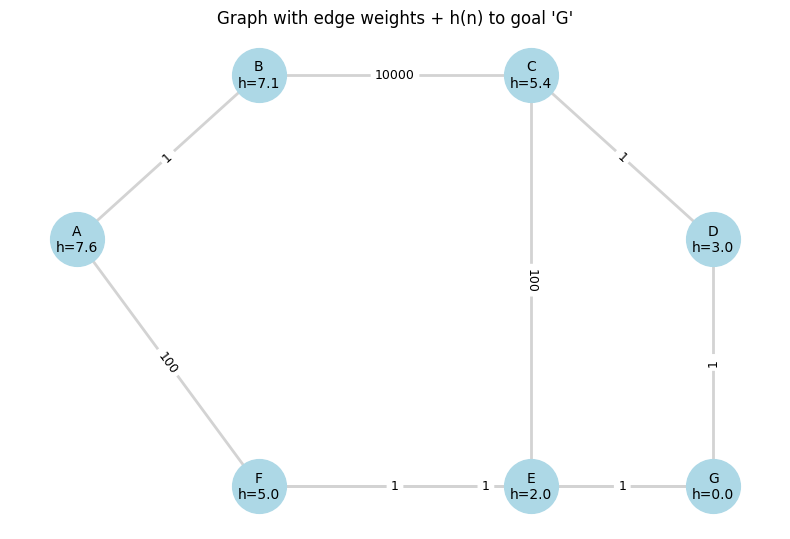

In [ ]:
def draw_graph(graph, goal=None, highlight_path=None, title=""):
    G_ = nx.Graph()
    for u in graph:
        for v, w in graph[u]:
            G_.add_edge(u, v, weight=w)

    plt.figure(figsize=(8, 5.5))
    nx.draw_networkx_edges(G_, nodes, edge_color='lightgray', width=2)
    nx.draw_networkx_nodes(G_, nodes, node_color='lightblue', node_size=1500)

    labels = {}
    for n in nodes:
        if goal is not None:
            labels[n] = n + "\nh=" + str(round(heuristic(n, goal), 1))
        else:
            labels[n] = n
    nx.draw_networkx_labels(G_, nodes, labels=labels, font_size=10)

    edge_labels = nx.get_edge_attributes(G_, 'weight')
    nx.draw_networkx_edge_labels(G_, nodes, edge_labels=edge_labels, font_size=9)

    if highlight_path:
        path_edges = []
        for i in range(len(highlight_path) - 1):
            path_edges.append((highlight_path[i], highlight_path[i + 1]))

        nx.draw_networkx_edges(G_, nodes, edgelist=path_edges, edge_color='red', width=3)
        nx.draw_networkx_nodes(G_, nodes, nodelist=highlight_path, node_color='salmon', node_size=1500)
        nx.draw_networkx_nodes(G_, nodes, nodelist=[highlight_path[0]], node_color='lightgreen', node_size=1600)
        nx.draw_networkx_nodes(G_, nodes, nodelist=[highlight_path[-1]], node_color='gold', node_size=1600)

    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

draw_graph(graph, goal='G', title="Graph with edge weights + h(n) to goal 'G'")

## Step 5 — A* Search (simple version)

Just like in C: keep a priority queue (`heapq`), and keep a `visited` set (like a `bool visited[N]` array).

Every step:
1. Pop the node with the smallest `f` value from the priority queue
2. If it's the goal — done, return the path
3. If it's already visited — skip it, move on
4. Otherwise, mark it visited, and push all of its neighbours into the queue

`f = g + h` , `g` = actual cost paid so far, `h` = estimated cost remaining to the goal.

In [ ]:
def astar_search(graph, start, goal):
    # each entry in the priority queue: (f, node_name, path_so_far, g)
    pq = []
    heapq.heappush(pq, (heuristic(start, goal), start, [start], 0))

    visited = set()   # like bool visited[N] = {False} in C

    while len(pq) > 0:
        f, node, path, g = heapq.heappop(pq)

        if node == goal:
            return path, g          # found it! return the path and total cost

        if node in visited:
            continue                # already processed this node, skip

        visited.add(node)

        for neighbor, cost in graph[node]:
            if neighbor not in visited:
                new_g = g + cost
                new_f = new_g + heuristic(neighbor, goal)   # f(n) = g(n) + h(n)
                heapq.heappush(pq, (new_f, neighbor, path + [neighbor], new_g))

    return None, None   # queue is empty, no path found to the goal

## Run it!
You can change `start` and `goal` here.

Path: A -> F -> G
Total cost: 101


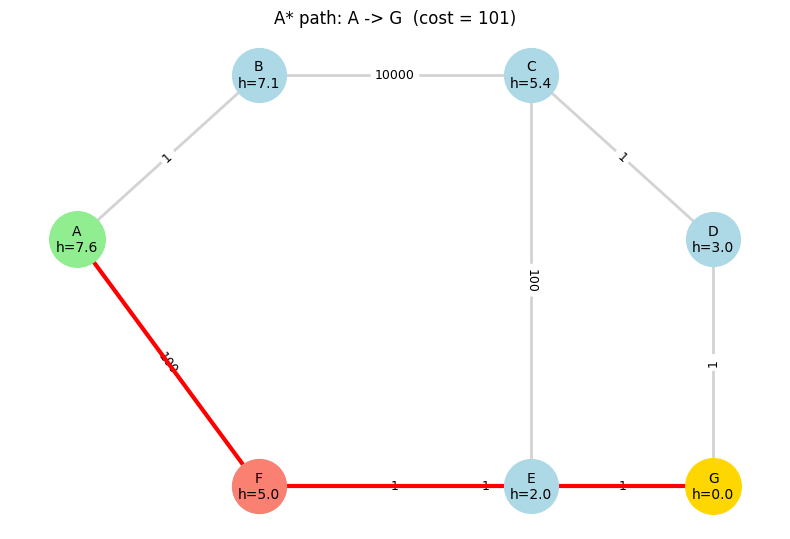

In [ ]:
start = 'A'
goal = 'G'

path, cost = astar_search(graph, start, goal)

if path is None:
    print("No path found.")
else:
    print("Path:", " -> ".join(path))
    print("Total cost:", cost)


    draw_graph(graph, goal=goal, highlight_path=path,
               title="A* path: " + start + " -> " + goal + "  (cost = " + str(cost) + ")")